<a href="https://colab.research.google.com/github/subudear/deep-learning/blob/main/assignment1/GAN/dcgan_resnet_petridish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DC-GAN + ResNet50 — Petri Dish Cell Classification

## How DC-GAN solves class imbalance

```
Real minority-class images
        │
        ▼
┌───────────────────┐     noise z ~ N(0,I)
│  GENERATOR (G)    │◄────────────────────
│  ConvTranspose    │◄──── class label c
│  blocks           │
└───────┬───────────┘
        │ fake images
        ▼
┌───────────────────┐◄──── real images
│  DISCRIMINATOR(D) │◄──── class label c
│  Conv blocks      │
└───────┬───────────┘
        │ real / fake?
        ▼
    BCE loss → G fools D, D detects fakes
```

**Process:**
1. Conditional DC-GAN trains on minority-class real images → G learns class-specific cell morphology
2. Generate synthetic images to bring every minority class up to GAN_TARGET images
3. Augment training dataframe with synthetic images (val set is never touched)
4. ResNet50 classifies the balanced dataset using:
   - `CrossEntropyLoss` → pushes different classes apart (↑ inter-class margin)
   - `CenterLoss` → pulls same-class features toward their class center (↓ intra-class variance)
   - Combined: `L = L_CE + 0.01 * L_center`

*Reference: Ma et al. "Combining DC-GAN with ResNet for blood cell image classification", Medical & Biological Engineering & Computing, 2020*

## STEP 1 — Imports & GPU check

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name:', torch.cuda.get_device_name(0))
    print('GPU memory:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

GPU available: True
GPU name: Tesla T4
GPU memory: 15.6 GB
Using device: cuda


## STEP 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## STEP 3 — Extract dataset

In [3]:
dataset_path = '/content/drive/MyDrive/compx525assign1/cell_cultures'
extract_path = '/content/datasetresnet'
os.makedirs(extract_path, exist_ok=True)
for f in os.listdir(dataset_path):
    if f.endswith('.zip'):
        zip_path = os.path.join(dataset_path, f)
        print('Extracting:', zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(extract_path)
print('Done. Folders:', os.listdir(extract_path))

Extracting: /content/drive/MyDrive/compx525assign1/cell_cultures/test.zip
Extracting: /content/drive/MyDrive/compx525assign1/cell_cultures/train.zip
Done. Folders: ['train', 'test']


## STEP 4 — Define paths & audit dataset

In [4]:
train_dir  = '/content/datasetresnet/train'
test_dir   = '/content/datasetresnet/test'
image_exts = ('.jpg', '.jpeg', '.png')

print('=== DATASET AUDIT ===')
class_counts = {}
for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    if not os.path.isdir(cls_path):
        continue
    n = sum(f.lower().endswith(image_exts) for f in os.listdir(cls_path))
    class_counts[cls] = n
    tier = 'EMPTY' if n == 0 else 'EXTREME(<15)' if n < 15 else 'MINORITY(<100)' if n < 100 else 'OK'
    print(f'  {cls}: {n:5d}  [{tier}]')

test_imgs = [f for f in os.listdir(test_dir) if f.lower().endswith(image_exts)]
print(f'\nTotal classes: {len(class_counts)}')
print(f'Total train images: {sum(class_counts.values())}')
print(f'Total test images:  {len(test_imgs)}')

EMPTY_CLASSES = [c for c, n in class_counts.items() if n == 0]
EXTREME_CLASSES = [c for c, n in class_counts.items() if 0 < n < 15]
GAN_CLASSES = [c for c, n in class_counts.items() if 0 < n < 100]  # DC-GAN targets all classes with < 100 images
print(f'\nEmpty (excluded):       {EMPTY_CLASSES}')
print(f'Extreme minority (<15): {EXTREME_CLASSES}')
print(f'GAN augment targets:    {GAN_CLASSES}')

=== DATASET AUDIT ===
  a:  1283  [OK]
  b:     4  [EXTREME(<15)]
  c:   475  [OK]
  d:   266  [OK]
  e:   117  [OK]
  f:    59  [MINORITY(<100)]
  g:   720  [OK]
  h:     5  [EXTREME(<15)]
  i:   199  [OK]
  j:     0  [EMPTY]
  k:    12  [EXTREME(<15)]
  l:   660  [OK]
  m:   543  [OK]
  n:    91  [MINORITY(<100)]
  o:   197  [OK]
  p:    35  [MINORITY(<100)]
  q:    29  [MINORITY(<100)]

Total classes: 17
Total train images: 4695
Total test images:  512

Empty (excluded):       ['j']
Extreme minority (<15): ['b', 'h', 'k']
GAN augment targets:    ['b', 'f', 'h', 'k', 'n', 'p', 'q']


## STEP 5 — Build training dataframe, train/val split & label encoding

In [5]:
rows = []
for cls, n in class_counts.items():
    if cls in EMPTY_CLASSES:
        continue
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(image_exts):
            rows.append({'filepath': os.path.join(cls_path, fname), 'label': cls})

train_df = pd.DataFrame(rows)
print(f'Total usable training images: {len(train_df)}')

# Extreme minority classes go to train only — too few for a reliable val split
extreme_df    = train_df[train_df['label'].isin(EXTREME_CLASSES)].copy()
splittable_df = train_df[~train_df['label'].isin(EXTREME_CLASSES)].copy()
train_split_df, val_split_df = train_test_split(
    splittable_df, test_size=0.2, stratify=splittable_df['label'], random_state=42)
train_split_df = pd.concat([train_split_df, extreme_df], ignore_index=True)

all_labels   = sorted(train_df['label'].unique())
label_to_idx = {label: idx for idx, label in enumerate(all_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
num_classes  = len(label_to_idx)

train_split_df = train_split_df.copy()
val_split_df   = val_split_df.copy()
train_split_df['label_idx'] = train_split_df['label'].map(label_to_idx)
val_split_df['label_idx']   = val_split_df['label'].map(label_to_idx)

print(f'Train: {len(train_split_df)}  |  Val: {len(val_split_df)}  |  Classes: {num_classes}')
print('label_to_idx:', label_to_idx)

Total usable training images: 4695
Train: 3760  |  Val: 935  |  Classes: 16
label_to_idx: {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'k': 9, 'l': 10, 'm': 11, 'n': 12, 'o': 13, 'p': 14, 'q': 15}


## STEP 6 — Define Conditional DC-GAN

### Generator
```
noise(100) + class_emb(50) → Linear → 512×4×4
→ ConvTranspose 256  8×8
→ ConvTranspose 128  16×16
→ ConvTranspose  64  32×32
→ ConvTranspose   3  64×64  (Tanh, range [-1,1])
```
### Discriminator
```
image(3,64,64) + label_map(1,64,64) → 4 channels input
→ Conv 64 → Conv 128 → Conv 256 → Conv 512 → Conv 1 → Sigmoid
```

In [6]:
GAN_IMG_SIZE   = 64
GAN_NOISE_DIM  = 100
GAN_LABEL_EMB  = 50
GAN_EPOCHS     = 200
GAN_BATCH_SIZE = 64
GAN_LR         = 2e-4
GAN_TARGET     = 200   # target images per minority class after augmentation


class Generator(nn.Module):
    """
    Conditional DC-GAN Generator.
    noise(100) + class_embedding(50) → 64x64 RGB image conditioned on class label.
    """
    def __init__(self, noise_dim, num_classes, label_emb_dim):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, label_emb_dim)
        in_dim = noise_dim + label_emb_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512 * 4 * 4),
            nn.Unflatten(1, (512, 4, 4)),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128,  64, 4, 2, 1, bias=False), nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d( 64,   3, 4, 2, 1, bias=False), nn.Tanh(),
        )
    def forward(self, noise, labels):
        return self.net(torch.cat([noise, self.label_emb(labels)], dim=1))


class Discriminator(nn.Module):
    """
    Conditional DC-GAN Discriminator.
    Projects class label to spatial map → concatenated as 4th input channel.
    """
    def __init__(self, num_classes, label_emb_dim, img_size=64):
        super().__init__()
        self.img_size   = img_size
        self.label_emb  = nn.Embedding(num_classes, label_emb_dim)
        self.label_proj = nn.Linear(label_emb_dim, img_size * img_size)
        self.net = nn.Sequential(
            nn.Conv2d(4,   64,  4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64,  128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False), nn.BatchNorm2d(512), nn.LeakyReLU(0.2, True),
            nn.Conv2d(512,   1, 4, 1, 0, bias=False), nn.Sigmoid(),
        )
    def forward(self, img, labels):
        lmap = self.label_proj(self.label_emb(labels)).view(-1, 1, self.img_size, self.img_size)
        return self.net(torch.cat([img, lmap], dim=1)).view(-1)


def weights_init(m):
    """Standard DC-GAN weight init: Conv from N(0,0.02), BatchNorm from N(1,0.02)."""
    name = m.__class__.__name__
    if 'Conv' in name or 'Linear' in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

print('DC-GAN architecture defined.')

DC-GAN architecture defined.


## STEP 7 — Train DC-GAN on minority classes

**Healthy training signs:** `D_loss ~1.0–1.4`, `G_loss ~1.5–3.0`
- If `D_loss → 0`: discriminator dominates, generator collapsed → reduce D LR or train G more
- If `G_loss → 0`: generator dominates / mode collapse → reduce G LR

In [7]:
gan_class_list   = sorted(GAN_CLASSES)
gan_label_to_idx = {c: i for i, c in enumerate(gan_class_list)}
num_gan_classes  = len(gan_class_list)

gan_rows = [r for r in rows if r['label'] in gan_class_list]
gan_df   = pd.DataFrame(gan_rows)
gan_df['label_idx'] = gan_df['label'].map(gan_label_to_idx)
print(f'GAN training: {num_gan_classes} minority classes, {len(gan_df)} real images')
print(gan_df['label'].value_counts().sort_index())

gan_transform = transforms.Compose([
    transforms.Resize((GAN_IMG_SIZE, GAN_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

class GANDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return self.transform(Image.open(row['filepath']).convert('RGB')), int(row['label_idx'])

gan_loader = DataLoader(GANDataset(gan_df, gan_transform),
                        batch_size=GAN_BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True, drop_last=True)

netG = Generator(GAN_NOISE_DIM, num_gan_classes, GAN_LABEL_EMB).to(device)
netD = Discriminator(num_gan_classes, GAN_LABEL_EMB, GAN_IMG_SIZE).to(device)
netG.apply(weights_init)
netD.apply(weights_init)

optD = torch.optim.Adam(netD.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
optG = torch.optim.Adam(netG.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
gan_criterion = nn.BCELoss()

print(f'Generator:     {sum(p.numel() for p in netG.parameters()):,} params')
print(f'Discriminator: {sum(p.numel() for p in netD.parameters()):,} params')
print(f'Training for {GAN_EPOCHS} epochs ...')

REAL_LABEL = 0.9  # label smoothing for real samples
FAKE_LABEL = 0.0

for epoch in range(GAN_EPOCHS):
    d_total, g_total, n_batches = 0.0, 0.0, 0
    for real_imgs, labels in gan_loader:
        real_imgs, labels = real_imgs.to(device), labels.to(device)
        b = real_imgs.size(0)
        # Train Discriminator
        netD.zero_grad()
        d_real = gan_criterion(netD(real_imgs, labels), torch.full((b,), REAL_LABEL, device=device))
        d_real.backward()
        fake = netG(torch.randn(b, GAN_NOISE_DIM, device=device), labels)
        d_fake = gan_criterion(netD(fake.detach(), labels), torch.full((b,), FAKE_LABEL, device=device))
        d_fake.backward()
        optD.step()
        # Train Generator
        netG.zero_grad()
        g_loss = gan_criterion(netD(fake, labels), torch.full((b,), REAL_LABEL, device=device))
        g_loss.backward()
        optG.step()
        d_total += d_real.item() + d_fake.item()
        g_total += g_loss.item()
        n_batches += 1
    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f'  Epoch [{epoch+1:3d}/{GAN_EPOCHS}]  D_loss: {d_total/n_batches:.4f}  G_loss: {g_total/n_batches:.4f}')

torch.save({'netG': netG.state_dict(), 'gan_class_list': gan_class_list,
            'gan_label_to_idx': gan_label_to_idx},
           '/content/drive/MyDrive/dcgan_petridish_resnet.pth')
print('GAN training complete. Model saved.')

GAN training: 7 minority classes, 235 real images
label
b     4
f    59
h     5
k    12
n    91
p    35
q    29
Name: count, dtype: int64
Generator:     3,993,822 params
Discriminator: 2,975,838 params
Training for 200 epochs ...
  Epoch [  1/200]  D_loss: 1.6141  G_loss: 6.0546
  Epoch [ 25/200]  D_loss: 0.9987  G_loss: 5.5667
  Epoch [ 50/200]  D_loss: 0.6301  G_loss: 3.9358
  Epoch [ 75/200]  D_loss: 0.8302  G_loss: 6.9080
  Epoch [100/200]  D_loss: 0.7370  G_loss: 6.4664
  Epoch [125/200]  D_loss: 0.7910  G_loss: 6.9681
  Epoch [150/200]  D_loss: 0.5983  G_loss: 4.1194
  Epoch [175/200]  D_loss: 0.6121  G_loss: 4.8951
  Epoch [200/200]  D_loss: 0.6409  G_loss: 3.9827
GAN training complete. Model saved.


## STEP 8 — Generate synthetic images & augment training dataframe

Synthetic images are saved to `/content/gan_generated/` and merged into `train_split_df` only.
`val_split_df` is **never modified** — validation always uses real images only.

In [8]:
print('Generating synthetic images for minority classes ...')
gan_gen_dir = '/content/gan_generated'
os.makedirs(gan_gen_dir, exist_ok=True)

def tensor_to_pil(t):
    """Convert [-1,1] normalised tensor back to PIL Image."""
    arr = ((t.clamp(-1, 1) + 1) * 127.5).byte().cpu().permute(1, 2, 0).numpy()
    return Image.fromarray(arr)

netG.eval()
generated_rows = []

with torch.no_grad():
    for cls in gan_class_list:
        existing = class_counts[cls]
        to_gen   = max(0, GAN_TARGET - existing)
        if to_gen == 0:
            print(f'  [{cls}] {existing} images — already at target, skipping')
            continue
        cls_dir = os.path.join(gan_gen_dir, cls)
        os.makedirs(cls_dir, exist_ok=True)
        cls_idx   = gan_label_to_idx[cls]
        generated = 0
        while generated < to_gen:
            batch = min(GAN_BATCH_SIZE, to_gen - generated)
            noise = torch.randn(batch, GAN_NOISE_DIM, device=device)
            lbls  = torch.full((batch,), cls_idx, dtype=torch.long, device=device)
            fakes = netG(noise, lbls)
            for i, img_t in enumerate(fakes):
                fpath = os.path.join(cls_dir, f'gan_{cls}_{generated+i:05d}.png')
                tensor_to_pil(img_t).save(fpath)
                generated_rows.append({'filepath': fpath, 'label': cls})
            generated += batch
        print(f'  [{cls}] {existing} real + {to_gen} synthetic = {existing+to_gen} total')

gen_df = pd.DataFrame(generated_rows)
gen_df['label_idx'] = gen_df['label'].map(label_to_idx)

# Merge synthetic images into TRAINING split only — val set is never augmented
train_split_df_aug = (
    pd.concat([train_split_df, gen_df], ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(f'\nOriginal train:  {len(train_split_df)}')
print(f'Augmented train: {len(train_split_df_aug)}')
print('\nPost-GAN class distribution:')
print(train_split_df_aug['label'].value_counts().sort_index())

Generating synthetic images for minority classes ...
  [b] 4 real + 196 synthetic = 200 total
  [f] 59 real + 141 synthetic = 200 total
  [h] 5 real + 195 synthetic = 200 total
  [k] 12 real + 188 synthetic = 200 total
  [n] 91 real + 109 synthetic = 200 total
  [p] 35 real + 165 synthetic = 200 total
  [q] 29 real + 171 synthetic = 200 total

Original train:  3760
Augmented train: 4925

Post-GAN class distribution:
label
a    1026
b     200
c     380
d     213
e      94
f     188
g     576
h     200
i     159
k     200
l     528
m     434
n     182
o     158
p     193
q     194
Name: count, dtype: int64


## STEP 9 — Classifier transforms, Dataset & Center Loss

**Center Loss** (Wen et al., 2016) combined with CrossEntropy:
- `CrossEntropyLoss` → pushes different classes apart (↑ inter-class margin)
- `CenterLoss` → pulls same-class features toward their class center (↓ intra-class variance)
- Combined: `L = L_CE + λ * L_center`  (λ=0.01 keeps CE as the dominant signal)

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.15),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class CenterLoss(nn.Module):
    """
    Center Loss — penalises intra-class feature scatter.
    Centers are learned parameters updated jointly via backprop.
    λ=0.01: small weight keeps CE as the dominant signal.
    """
    def __init__(self, num_classes, feat_dim):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(num_classes, feat_dim))

    def forward(self, features, labels):
        centers_batch = self.centers[labels]
        return 0.5 * ((features - centers_batch) ** 2).sum(dim=1).mean()


class ImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return self.transform(Image.open(row['filepath']).convert('RGB')), int(row['label_idx'])


BATCH_SIZE    = 32
CENTER_LAMBDA = 0.01

train_dataset = ImageDataset(train_split_df_aug, train_transform)
val_dataset   = ImageDataset(val_split_df,       val_transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

counts = train_split_df_aug['label_idx'].value_counts().sort_index()
cw = 1.0 / torch.tensor(counts.values, dtype=torch.float).sqrt()
cw = (cw / cw.sum() * num_classes).to(device)
ce_criterion   = nn.CrossEntropyLoss(weight=cw)
center_loss_fn = CenterLoss(num_classes, feat_dim=2048).to(device)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train batches: 154  |  Val batches: 30


## STEP 10 — Build ResNet50 classifier

In [10]:
class ResNetClassifier(nn.Module):
    """
    ResNet50 with pretrained ImageNet weights.
    Returns (logits, features): logits for CE loss, features for Center loss.
    """
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.features   = nn.Sequential(*list(backbone.children())[:-1])  # → [B, 2048, 1, 1]
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(2048, num_classes)

    def forward(self, x):
        feat   = self.features(x).view(x.size(0), -1)   # [B, 2048]
        feat_d = self.dropout(feat)
        logits = self.classifier(feat_d)
        return logits, feat   # feat (pre-dropout) used for center loss


resnet_model = ResNetClassifier(num_classes).to(device)
print(f'Total params: {sum(p.numel() for p in resnet_model.parameters()):,}')
best_resnet_path = '/content/drive/MyDrive/dcgan_resnet_best.pth'

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 139MB/s]


Total params: 23,540,816


## STEP 11 — Phase 1: Train classifier head only (10 epochs)

Backbone frozen. Initialises head weights before any backbone gradients flow.

In [11]:
for param in resnet_model.features.parameters():
    param.requires_grad = False
for param in resnet_model.classifier.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(resnet_model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

num_epochs   = 10
best_val_acc = 0.0
print(f'Phase 1 trainable params: {sum(p.numel() for p in resnet_model.parameters() if p.requires_grad):,}')

for epoch in range(num_epochs):
    resnet_model.train()
    run_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits, feat = resnet_model(images)
        loss = ce_criterion(logits, labels) + CENTER_LAMBDA * center_loss_fn(feat, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(resnet_model.parameters(), max_norm=1.0)
        optimizer.step()
        run_loss += loss.item()
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += labels.size(0)
    scheduler.step()

    resnet_model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            logits, _ = resnet_model(images.to(device))
            val_correct += (logits.argmax(1) == labels.to(device)).sum().item()
            val_total   += labels.size(0)
    val_acc = val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'model_state_dict': resnet_model.state_dict(),
                    'label_to_idx': label_to_idx, 'idx_to_label': idx_to_label,
                    'best_val_acc': best_val_acc}, best_resnet_path)
        print(f'  --> Saved (val_acc={val_acc:.4f})')
    print(f'Phase 1 | Ep {epoch+1}/{num_epochs} | Loss: {run_loss/len(train_loader):.4f} | '
          f'Train: {correct/total:.4f} | Val: {val_acc:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}')
print(f'Phase 1 best val acc: {best_val_acc:.4f}')

Phase 1 trainable params: 32,784
  --> Saved (val_acc=0.3337)
Phase 1 | Ep 1/10 | Loss: 12.9956 | Train: 0.3358 | Val: 0.3337 | LR: 9.76e-04
  --> Saved (val_acc=0.3711)
Phase 1 | Ep 2/10 | Loss: 12.6474 | Train: 0.4323 | Val: 0.3711 | LR: 9.05e-04
  --> Saved (val_acc=0.4011)
Phase 1 | Ep 3/10 | Loss: 12.5363 | Train: 0.4759 | Val: 0.4011 | LR: 7.94e-04
  --> Saved (val_acc=0.4075)
Phase 1 | Ep 4/10 | Loss: 12.4496 | Train: 0.4930 | Val: 0.4075 | LR: 6.55e-04
Phase 1 | Ep 5/10 | Loss: 12.3921 | Train: 0.5019 | Val: 0.3786 | LR: 5.00e-04
Phase 1 | Ep 6/10 | Loss: 12.3702 | Train: 0.5123 | Val: 0.3893 | LR: 3.45e-04
Phase 1 | Ep 7/10 | Loss: 12.3373 | Train: 0.5259 | Val: 0.4053 | LR: 2.06e-04
Phase 1 | Ep 8/10 | Loss: 12.3252 | Train: 0.5230 | Val: 0.4043 | LR: 9.55e-05
Phase 1 | Ep 9/10 | Loss: 12.3167 | Train: 0.5204 | Val: 0.4021 | LR: 2.45e-05
Phase 1 | Ep 10/10 | Loss: 12.3190 | Train: 0.5304 | Val: 0.4011 | LR: 0.00e+00
Phase 1 best val acc: 0.4075


## STEP 12 — Phase 2: Fine-tune layer3 + layer4 + head (30 epochs)

In [12]:
checkpoint = torch.load(best_resnet_path, map_location=device)
resnet_model.load_state_dict(checkpoint['model_state_dict'])

for param in resnet_model.parameters():
    param.requires_grad = False
# ResNet50 children: conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool
# In our features Sequential: index 6=layer3, 7=layer4, 8=avgpool
for child_idx in [6, 7, 8]:
    for param in list(resnet_model.features.children())[child_idx].parameters():
        param.requires_grad = True
for param in resnet_model.classifier.parameters():
    param.requires_grad = True
for param in center_loss_fn.parameters():
    param.requires_grad = True

trainable_params = (
    list(filter(lambda p: p.requires_grad, resnet_model.parameters())) +
    list(center_loss_fn.parameters())
)
print(f'Phase 2 trainable params: {sum(p.numel() for p in trainable_params):,}')

optimizer = torch.optim.Adam(trainable_params, lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

num_epochs = 30
for epoch in range(num_epochs):
    resnet_model.train()
    run_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits, feat = resnet_model(images)
        loss = ce_criterion(logits, labels) + CENTER_LAMBDA * center_loss_fn(feat, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(resnet_model.parameters(), max_norm=1.0)
        optimizer.step()
        run_loss += loss.item()
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += labels.size(0)

    resnet_model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            logits, _ = resnet_model(images.to(device))
            val_correct += (logits.argmax(1) == labels.to(device)).sum().item()
            val_total   += labels.size(0)
    val_acc = val_correct / val_total
    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'model_state_dict': resnet_model.state_dict(),
                    'label_to_idx': label_to_idx, 'idx_to_label': idx_to_label,
                    'best_val_acc': best_val_acc}, best_resnet_path)
        print(f'  --> Saved at epoch {epoch+1} (val_acc={val_acc:.4f})')
    print(f'Phase 2 | Ep {epoch+1}/{num_epochs} | Loss: {run_loss/len(train_loader):.4f} | '
          f'Train: {correct/total:.4f} | Val: {val_acc:.4f} | LR: {current_lr:.2e}')
print(f'Phase 2 best val acc: {best_val_acc:.4f}')

Phase 2 trainable params: 22,128,656
  --> Saved at epoch 1 (val_acc=0.5658)
Phase 2 | Ep 1/30 | Loss: 11.5147 | Train: 0.6262 | Val: 0.5658 | LR: 1.00e-04
  --> Saved at epoch 2 (val_acc=0.6310)
Phase 2 | Ep 2/30 | Loss: 10.1735 | Train: 0.6989 | Val: 0.6310 | LR: 1.00e-04
  --> Saved at epoch 3 (val_acc=0.6481)
Phase 2 | Ep 3/30 | Loss: 9.1719 | Train: 0.7330 | Val: 0.6481 | LR: 1.00e-04
  --> Saved at epoch 4 (val_acc=0.6781)
Phase 2 | Ep 4/30 | Loss: 8.5182 | Train: 0.7574 | Val: 0.6781 | LR: 1.00e-04
Phase 2 | Ep 5/30 | Loss: 8.0415 | Train: 0.7805 | Val: 0.6652 | LR: 1.00e-04
  --> Saved at epoch 6 (val_acc=0.6856)
Phase 2 | Ep 6/30 | Loss: 7.6726 | Train: 0.7870 | Val: 0.6856 | LR: 1.00e-04
  --> Saved at epoch 7 (val_acc=0.6963)
Phase 2 | Ep 7/30 | Loss: 7.3414 | Train: 0.8028 | Val: 0.6963 | LR: 1.00e-04
Phase 2 | Ep 8/30 | Loss: 7.0547 | Train: 0.8187 | Val: 0.6963 | LR: 1.00e-04
Phase 2 | Ep 9/30 | Loss: 6.7804 | Train: 0.8223 | Val: 0.6920 | LR: 1.00e-04
  --> Saved at epoc

## STEP 13 — Evaluate best model on validation set

Evaluating best model (val_acc=0.7209)


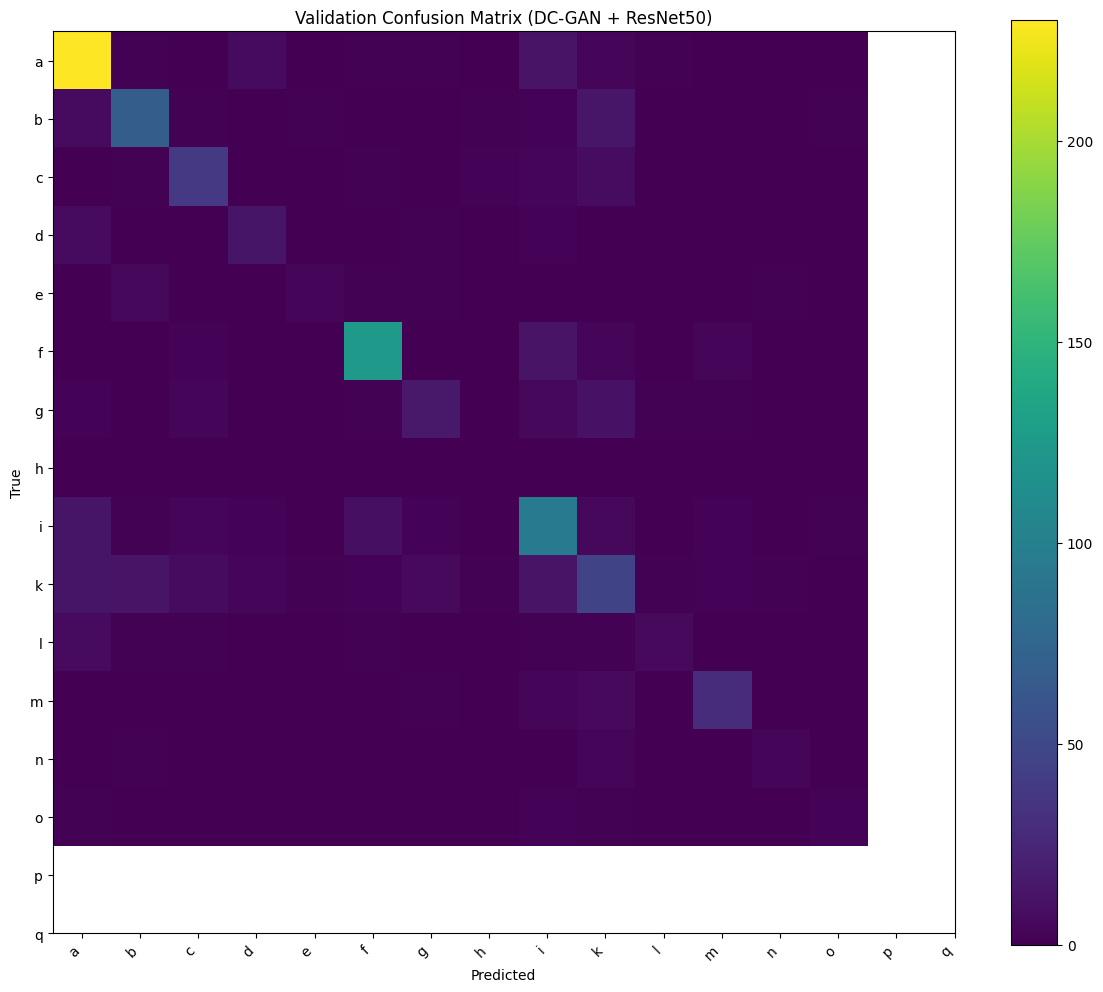

ValueError: Number of classes, 14, does not match size of target_names, 16. Try specifying the labels parameter

In [13]:
checkpoint = torch.load(best_resnet_path, map_location=device)
resnet_model.load_state_dict(checkpoint['model_state_dict'])
resnet_model.eval()
print(f'Evaluating best model (val_acc={checkpoint["best_val_acc"]:.4f})')

all_true, all_pred = [], []
with torch.no_grad():
    for images, labels in val_loader:
        logits, _ = resnet_model(images.to(device))
        all_true.extend(labels.numpy())
        all_pred.extend(logits.argmax(1).cpu().numpy())

class_names = [idx_to_label[i] for i in range(num_classes)]
cm = confusion_matrix(all_true, all_pred, labels=list(range(num_classes)))

plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest')
plt.title('Validation Confusion Matrix (DC-GAN + ResNet50)')
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print(classification_report(all_true, all_pred, labels=list(range(num_classes)), target_names=class_names, zero_division=0))

## STEP 14 — Build test DataLoader & generate submission CSV

In [ ]:
class TestDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return self.transform(Image.open(row['filepath']).convert('RGB')), row['filename']

test_rows = [{'filepath': os.path.join(test_dir, f), 'filename': f}
             for f in sorted(os.listdir(test_dir)) if f.lower().endswith(image_exts)]
test_df      = pd.DataFrame(test_rows)
test_dataset = TestDataset(test_df, val_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Test images: {len(test_df)}  |  Batches: {len(test_loader)}')

resnet_model.eval()
all_filenames, all_preds = [], []
with torch.no_grad():
    for images, filenames in test_loader:
        logits, _ = resnet_model(images.to(device))
        all_filenames.extend(filenames)
        all_preds.extend([idx_to_label[p.item()] for p in logits.argmax(1).cpu()])

submission_df = pd.DataFrame({'TestFileName': all_filenames, 'Class': all_preds})
csv_path = '/content/drive/MyDrive/dcgan_resnet_submission.csv'
submission_df.to_csv(csv_path, index=False)

print(submission_df.head(10))
print(f'\nPrediction distribution:\n{submission_df["Class"].value_counts().sort_index()}')
print(f'\nSaved to: {csv_path}')